In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import os
import shapely
# import geopandas as gpd

import skimage as ski
from skimage.morphology import dilation, square
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.transform import rescale, resize, downscale_local_mean

C:\Users\marie\anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
kp_dir = r"..\data\pred_labels_v2\keypoints"
sg_dir = r"..\data\pred_labels_v2\segments"
im_dir = r"..\data\images"
out_dir = r"results"
kp_list = os.listdir(kp_dir)
cow_list = np.unique([file.split("_")[1] for file in kp_list])

def area_ratio(labels):
    values = np.max(labels)
    areas = []
    for value in range(values):
        area = len(labels[labels==value+1])
        areas.append(area)
    return max(areas)/min(areas)

In [ ]:
def sep_points(right_kp, left_kp, udder_shp):
    
    
angle = np.arccos(np.dot(rb_point.coords[0],lb_point.coords[0])/(np.linalg.norm(rb_point.coords[0]) * np.linalg.norm(lb_point.coords[0])))
nrb_point = shapely.Point([rb_point.coords[0][0] + 10*np.cos(-angle), rb_point.coords[0][1] + 10*np.sin(-angle)])
nlb_point = shapely.Point([lb_point.coords[0][0] - 10*np.cos(-angle), lb_point.coords[0][1] - 10*np.sin(-angle)])
# make sure they are still inside the udder
if udder_shp.contains(nrb_point):
    # update points 
    points2[2, :2] = np.round(nrb_point.coords[0], 0).astype(int)
if udder_shp.contains(nlb_point):
    points2[3, :2] = np.round(nlb_point.coords[0], 0).astype(int)

In [7]:
dil_factor = 30
ratio_limit = 4
iter_limit = 5

for cow in cow_list:
    filenames = [file for file in kp_list if file.split("_")[1]==cow]
    file_n = int(len(filenames)//2)
    file =  filenames[file_n]
    
    udder = ski.io.imread(os.path.join(im_dir, file.replace("txt", "tif")))
    # image shape is in y,x oder
    im_size = udder.shape
    im_height = im_size[0]
    im_width = im_size[1]
    
    # segments are in x,y oder 
    with open(os.path.join(sg_dir, file), "r") as f:
        mask = np.array([float(point) for point in f.read().split(" ")][1:])
    mask = mask.reshape((int(len(mask)//2),2))
    
    # keypoints are in x,y oder
    with open(os.path.join(kp_dir, file), "r") as f:
        data =  [float(point) for point in f.read().split(" ")]
        box = np.array(data[1:5])
        points = np.array(data[5:])
    points = points.reshape((4,3))
    box = box.reshape((2,2))
    box[:, 0] = box[:, 0] * im_width
    box[:, 1] = box[:, 1] * im_height
    box[0, 0] = box[0, 0] - box[1, 0]/2
    box[0, 1] = box[0, 1] - box[1, 1]/2
    
    points[:, 0] = points[:, 0] * im_width
    points[:, 1] = points[:, 1] * im_height

    # polygon requires y,x order
    ploygon = [[coord[1] * im_height, coord[0]*im_width] for coord in mask]
    mask2 = ski.draw.polygon2mask(im_size, ploygon)
    masked_udder = udder*mask2
    
    msk1 = [[coord[0]*im_width, coord[1] * im_height] for coord in mask]
    mask1 = np.zeros(im_size)
    
    points2 =np.round(points,0).astype(int)
    
    # location of teats
    rf_point = shapely.Point(points[0, :2])
    lf_point = shapely.Point(points[1, :2])
    rb_point = shapely.Point(points[2, :2])
    lb_point = shapely.Point(points[3, :2])

    udder_shp = shapely.Polygon(msk1)

    wd_front = shapely.distance(rf_point, lf_point)
    wd_back = shapely.distance(rb_point, lb_point)

    rf_ud = shapely.distance(udder_shp.exterior, rf_point)
    lf_ud = shapely.distance(udder_shp.exterior, lf_point)
    rb_ud = shapely.distance(udder_shp.exterior, rb_point)
    lb_ud = shapely.distance(udder_shp.exterior, lb_point)

    distances = {"wd_front": wd_front, "wd_back": wd_back, "rf_ud": rf_ud, "lf_ud":lf_ud, "rb_ud": rb_ud, "lb_ud": lb_ud}
    
    col = ".r"
    # if they are too close to each other move 10 units away 
    cnt = 0       
    while (wd_front < min(box[1, 0],  box[1, 1])/2) & (cnt < iter_limit):
        # then move 20 appart
        angle = np.arccos(np.dot(rf_point.coords[0],lf_point.coords[0])/(np.linalg.norm(rf_point.coords[0]) * np.linalg.norm(lf_point.coords[0])))
        nrf_point = shapely.Point([rf_point.coords[0][0] + 30*np.cos(-angle), rf_point.coords[0][1] + 30*np.sin(-angle)])
        nlf_point = shapely.Point([lf_point.coords[0][0] - 30*np.cos(-angle), lf_point.coords[0][1] - 30*np.sin(-angle)])
        # make sure they are still inside the udder
        if udder_shp.contains(nrf_point):
            # update points 
            points2[0, :2] = np.round(nrf_point.coords[0], 0).astype(int)
        if udder_shp.contains(nlf_point):
            points2[1, :2] = np.round(nlf_point.coords[0], 0).astype(int)
        wd_front = shapely.distance(nrf_point, nlf_point)
        cnt +=1
    
    cnt = 0       
    while (wd_back < min(box[1, 0],  box[1, 1])/2) & (cnt < iter_limit):
        # then move 20 appart
        angle = np.arccos(np.dot(rb_point.coords[0],lb_point.coords[0])/(np.linalg.norm(rb_point.coords[0]) * np.linalg.norm(lb_point.coords[0])))
        nrb_point = shapely.Point([rb_point.coords[0][0] + 10*np.cos(-angle), rb_point.coords[0][1] + 10*np.sin(-angle)])
        nlb_point = shapely.Point([lb_point.coords[0][0] - 10*np.cos(-angle), lb_point.coords[0][1] - 10*np.sin(-angle)])
        # make sure they are still inside the udder
        if udder_shp.contains(nrb_point):
            # update points 
            points2[2, :2] = np.round(nrb_point.coords[0], 0).astype(int)
        if udder_shp.contains(nlb_point):
            points2[3, :2] = np.round(nlb_point.coords[0], 0).astype(int)
        
        wd_back = shapely.distance(nrb_point, nlb_point)
        cnt +=1
    # if they are too close to the edge of the box move 10 units inside
    
    
    # marker locations
    mask1[points2[0, 1], points2[0,0]] = True
    mask1[points2[1, 1], points2[1,0]] = True
    mask1[points2[2, 1], points2[2,0]] = True
    mask1[points2[3, 1], points2[3,0]] = True
    
    mask1 = dilation(mask1,  square(dil_factor))
    markers, _ = ndi.label(mask1)
    # find segments
    labels = watershed(masked_udder, markers = markers, mask = mask2, watershed_line=True)
    
    # area of labels
    ratio = area_ratio(labels)
    print(f"1st. cow: {cow}, ratio: {ratio}")
    
    cnt = 0
    while (ratio > ratio_limit) & (cnt < iter_limit): # and the number of segements is 4
        mask1 = dilation(mask1,  square(10))
        markers, _ = ndi.label(mask1)
        labels2 = watershed(masked_udder, markers = markers, mask = mask2, watershed_line=True)
        num_segments = np.max(labels2)
        if num_segments < 4:
            break
        else:
            labels = labels2
        ratio = area_ratio(labels)
        num_segments = np.max(labels2)
        cnt +=1
        print(f"\t {cnt} cow: {cow}, ratio: {ratio}")
        
    # make a nice plot!
    fig, ax = plt.subplots()
    ax.imshow(labels, cmap=plt.cm.nipy_spectral)
    ax.plot(points2[0, 0], points2[0, 1], col) # right front
    ax.plot(points2[1, 0], points2[1, 1], col) # left front
    ax.plot(points2[2, 0], points2[2, 1], col) # right back
    ax.plot(points2[3, 0], points2[3, 1], col) # left back
    fig.savefig(os.path.join(out_dir, file.replace("txt", "png")))
    plt.close(fig)   

1st. cow: 125, ratio: 2.1291689299293863
1st. cow: 143, ratio: 6.963975472662238
	 1 cow: 143, ratio: 5.947414357407811
	 2 cow: 143, ratio: 5.687787536595566
1st. cow: 149, ratio: 4.022560712746084
	 1 cow: 149, ratio: 4.104136110296275
	 2 cow: 149, ratio: 4.153548579080494
1st. cow: 161, ratio: 2.662953306470728
1st. cow: 7916, ratio: 2.3585266030013643
1st. cow: 8196, ratio: 7.056236912952438
1st. cow: 8257, ratio: 1.3603904065917898
1st. cow: 8417, ratio: 1.2375843041079093
1st. cow: 8421, ratio: 2.217605340008344
1st. cow: 8435, ratio: 3.181886565367835
1st. cow: 8485, ratio: 1.1186028460543338
1st. cow: 8551, ratio: 11.358803986710964
	 1 cow: 8551, ratio: 6.656937026456341
	 2 cow: 8551, ratio: 3.265911927259761
1st. cow: 8558, ratio: 43.16536964980545
1st. cow: 8562, ratio: 15.152362948960302
	 1 cow: 8562, ratio: 10.450561197220738
	 2 cow: 8562, ratio: 9.074221493795363
1st. cow: 8642, ratio: 1.7843252799057159
1st. cow: 8667, ratio: 2.014605386573764
1st. cow: 8668, ratio: 

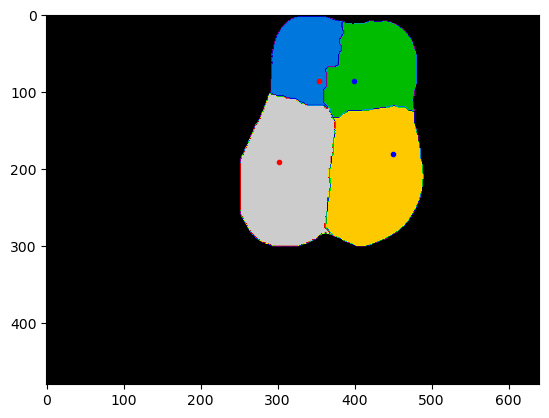

In [16]:
fig, ax = plt.subplots()
ax.imshow(labels, cmap=plt.cm.nipy_spectral)
ax.plot(points2[0, 0], points2[0, 1], ".b") # right front
ax.plot(points2[1, 0], points2[1, 1], ".r") # left front
ax.plot(points2[2, 0], points2[2, 1], ".b") # right back
ax.plot(points2[3, 0], points2[3, 1], ".r") # left back

In [7]:
import geopandas as gpd
rf_point = shapely.Point(points[0, :2])
lf_point = shapely.Point(points[1, :2])
rb_point = shapely.Point(points[2, :2])
lb_point = shapely.Point(points[3, :2])

udder_shp = shapely.Polygon(msk1)

wd_front = shapely.distance(rf_point, lf_point)
wd_back = shapely.distance(rb_point, lb_point)

rf_ud = shapely.distance(udder_shp.exterior, rf_point)
lf_ud = shapely.distance(udder_shp.exterior, lf_point)
rb_ud = shapely.distance(udder_shp.exterior, rb_point)
lb_ud = shapely.distance(udder_shp.exterior, lb_point)

distances = {"wd_front": wd_front, "wd_back": wd_back, "rf_ud": rf_ud, "lf_ud":lf_ud, "rb_ud": rb_ud, "lb_ud": lb_ud}

<Axes: >

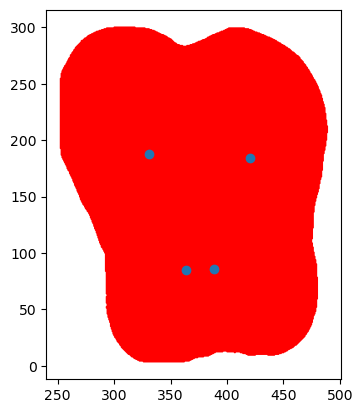

In [12]:
# obj = gpd.GeoSeries(box_polygon)
pts = gpd.GeoSeries([rf_point, lf_point, rb_point, lb_point])
msk = gpd.GeoSeries(udder_shp)
# nf = gpd.GeoSeries([new_point1, new_point2])
# box_polygon.contains(lf_point)

figure, ax = plt.subplots()
# p.plot(ax = ax)
msk.plot(ax = ax, color = "red")
pts.plot(ax = ax)
# nf.plot(ax = ax)

In [146]:
angle = np.arccos(np.dot(rf_point.coords[0],lf_point.coords[0])/(np.linalg.norm(rf_point.coords[0]) * np.linalg.norm(lf_point.coords[0])))
nrf_point = shapely.Point([rf_point.coords[0][0] + 30*np.cos(-angle), rf_point.coords[0][1] + 30*np.sin(-angle)])
nlf_point = shapely.Point([lf_point.coords[0][0] - 30*np.cos(-angle), lf_point.coords[0][1] - 30*np.sin(-angle)])